In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All imports successful")

Matplotlib is building the font cache; this may take a moment.


All imports successful


## Pulling the data

In [3]:
# Pull SPY and VIX data
spy = yf.download("SPY", start="2005-01-01", end="2024-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2005-01-01", end="2024-12-31", auto_adjust=True)

# Flatten MultiIndex columns if present
spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

# Keep only closing prices
spy_close = spy["Close"]
vix_close = vix["Close"]

# Compute SPY log returns
log_returns = np.log(spy_close / spy_close.shift(1)).dropna()

# Compute 21-day rolling realized volatility
realized_vol = log_returns.rolling(window=21).std() * np.sqrt(252)

# Align all three series on the same dates
data = pd.DataFrame({
    "log_returns": log_returns,
    "realized_vol": realized_vol,
    "vix": vix_close
}).dropna()

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"\nFirst 5 rows:")
data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Dataset shape: (5011, 3)
Date range: 2005-02-02 to 2024-12-30

First 5 rows:


,log_returns,realized_vol,vix
Date,,,
2005-02-02,0.003023,0.100448,11.66
2005-02-03,-0.002603,0.091182,11.79
2005-02-04,0.010619,0.094462,11.21
2005-02-07,-0.001332,0.093488,11.73
2005-02-08,0.001166,0.093215,11.60


## Plot of all three series

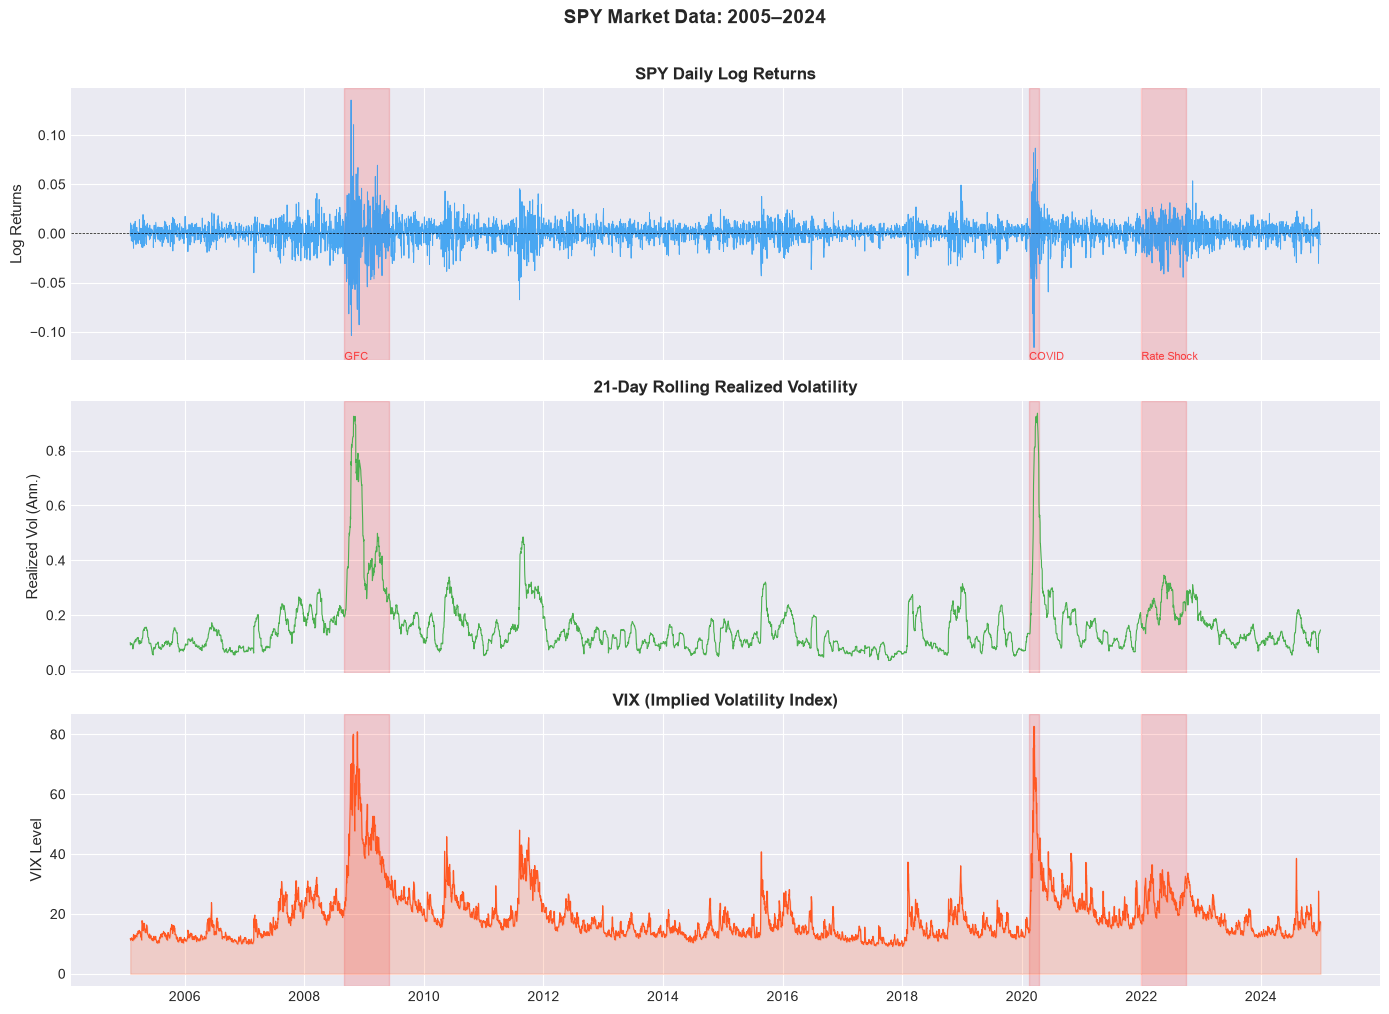

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1 - SPY Log Returns
axes[0].plot(data.index, data["log_returns"], color="#2196F3", linewidth=0.7, alpha=0.8)
axes[0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_ylabel("Log Returns", fontsize=11)
axes[0].set_title("SPY Daily Log Returns", fontsize=12, fontweight="bold")

# Shade known crisis periods for visual reference
crises = [
    ("2008-09-01", "2009-06-01", "GFC"),
    ("2020-02-15", "2020-04-15", "COVID"),
    ("2022-01-01", "2022-10-01", "Rate Shock")
]
for start, end, label in crises:
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), 
                   alpha=0.15, color="red")
    axes[0].text(pd.Timestamp(start), axes[0].get_ylim()[0], 
                 label, fontsize=8, color="red", alpha=0.7)

# Plot 2 - Realized Volatility
axes[1].plot(data.index, data["realized_vol"], color="#4CAF50", linewidth=0.8)
axes[1].set_ylabel("Realized Vol (Ann.)", fontsize=11)
axes[1].set_title("21-Day Rolling Realized Volatility", fontsize=12, fontweight="bold")

# Plot 3 - VIX
axes[2].plot(data.index, data["vix"], color="#FF5722", linewidth=0.8)
axes[2].fill_between(data.index, data["vix"], alpha=0.2, color="#FF5722")
axes[2].set_ylabel("VIX Level", fontsize=11)
axes[2].set_title("VIX (Implied Volatility Index)", fontsize=12, fontweight="bold")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("SPY Market Data: 2005–2024", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/01_raw_data.png", dpi=150, bbox_inches="tight")
plt.show()

- GCF 2008-2009: returns explode, realized vol hits ~.90 annualized, VIX spikes to 80
- 2020: same pattern, nearly identical vol spikes, VIX hits ~82
- 2022: more sustained, lower peak - different regime character than the acute crises

## Summary Statistics

In [7]:
# Summary statistics by feature
print("=== Summary Statistics ===\n")
print(data.describe().round(4))

print("\n=== Correlation Matrix ===\n")
print(data.corr().round(4))

print("\n=== Annualized Return & Volatility ===")
ann_return = data["log_returns"].mean() * 252
ann_vol = data["log_returns"].std() * np.sqrt(252)
print(f"SPY Annualized Return: {ann_return:.2%}")
print(f"SPY Annualized Volatility: {ann_vol:.2%}")
print(f"SPY Sharpe (assume 0% rf): {ann_return/ann_vol:.2f}")

print("\n=== VIX Statistics ===")
print(f"VIX Mean: {data['vix'].mean():.2f}")
print(f"VIX Median: {data['vix'].median():.2f}")
print(f"VIX Max: {data['vix'].max():.2f}")
print(f"VIX Min: {data['vix'].min():.2f}")

=== Summary Statistics ===

       log_returns  realized_vol        vix
count    5011.0000     5011.0000  5011.0000
mean        0.0004        0.1568    19.1782
std         0.0120        0.1108     8.7929
min        -0.1159        0.0342     9.1400
25%        -0.0040        0.0922    13.3500
50%         0.0007        0.1290    16.6900
75%         0.0058        0.1850    22.2700
max         0.1356        0.9367    82.6900

=== Correlation Matrix ===

              log_returns  realized_vol     vix
log_returns        1.0000       -0.0119 -0.1494
realized_vol      -0.0119        1.0000  0.8838
vix               -0.1494        0.8838  1.0000

=== Annualized Return & Volatility ===
SPY Annualized Return: 9.93%
SPY Annualized Volatility: 19.09%
SPY Sharpe (assume 0% rf): 0.52

=== VIX Statistics ===
VIX Mean: 19.18
VIX Median: 16.69
VIX Max: 82.69
VIX Min: 9.14


Correlation matrix finding:

Realized vol and VIX are correlates at .884. The .116 of independent variation justifies using both as HMM features. Realized vol is backward looking (what volatility actually was), VIX is forward looking (what the market expects volatility to be). Together they give both dimensions

VIX skew: mean of 19.18 but median of 16.69, distribution is right-skewed, pulled up by crisis spikes. The max of 82.69 vs a normal range of 9-22 confirms there are distinct regimes in this data